**NTI_final_project_Crop Yield Prediction**


---
Members:

* Menna Mohamed Ali
* Mariam Altourky









In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree  import  DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor


In [ ]:
df_not_encoded = pd.read_csv('yield_df.csv')
df_not_encoded.drop(columns=['Unnamed: 0'], inplace=True)

# 2. تجهيز الـ Encoder
encoder = OneHotEncoder(sparse_output=False, dtype=int)

# 3. عمل التحويل (ينتج مصفوفة NumPy)
encoded_array = encoder.fit_transform(df_not_encoded[['Item']])

# 4. تحويل المصفوفة إلى DataFrame مع تسمية الأعمدة بأسماء المحاصيل (Items)
encoded_cols = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Item']))

# 5. دمج الأعمدة الجديدة مع الجدول الأصلي وحذف عمود Item القديم
df = pd.concat([df_not_encoded.drop(columns=['Item']), encoded_cols], axis=1)



In [ ]:
#shows first 5 features
df.head()

,Area,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,Albania,1990,36613,1485.0,121.0,16.37,0,1,0,0,0,0,0,0,0,0
1,Albania,1990,66667,1485.0,121.0,16.37,0,0,0,1,0,0,0,0,0,0
2,Albania,1990,23333,1485.0,121.0,16.37,0,0,0,0,1,0,0,0,0,0
3,Albania,1990,12500,1485.0,121.0,16.37,0,0,0,0,0,1,0,0,0,0
4,Albania,1990,7000,1485.0,121.0,16.37,0,0,0,0,0,0,1,0,0,0


In [ ]:
# dy 101 diff count./unrep.
print(df['Area'].unique())

['Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Canada' 'Central African Republic' 'Chile' 'Colombia' 'Croatia'
 'Denmark' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Eritrea'
 'Estonia' 'Finland' 'France' 'Germany' 'Ghana' 'Greece' 'Guatemala'
 'Guinea' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'India' 'Indonesia' 'Iraq'
 'Ireland' 'Italy' 'Jamaica' 'Japan' 'Kazakhstan' 'Kenya' 'Latvia'
 'Lebanon' 'Lesotho' 'Libya' 'Lithuania' 'Madagascar' 'Malawi' 'Malaysia'
 'Mali' 'Mauritania' 'Mauritius' 'Mexico' 'Montenegro' 'Morocco'
 'Mozambique' 'Namibia' 'Nepal' 'Netherlands' 'New Zealand' 'Nicaragua'
 'Niger' 'Norway' 'Pakistan' 'Papua New Guinea' 'Peru' 'Poland' 'Portugal'
 'Qatar' 'Romania' 'Rwanda' 'Saudi Arabia' 'Senegal' 'Slovenia'
 'South Africa' 'Spain' 'Sri Lanka' 'Sudan' 'Suriname' 'Sweden'
 'Switzerland' 'Tajikistan

In [ ]:
# حساب نسبة تكرار كل منطقة
area_frequencies = df['Area'].value_counts(normalize=True)

# تطبيق المابينج بناءً على التكرار
df['Area_Encoded'] = df['Area'].map(area_frequencies)

# حذف العمود النصي القديم
df.drop(columns=['Area'], inplace=True)
df.head()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams,Area_Encoded
0,1990,36613,1485.0,121.0,16.37,0,1,0,0,0,0,0,0,0,0,0.003505
1,1990,66667,1485.0,121.0,16.37,0,0,0,1,0,0,0,0,0,0,0.003505
2,1990,23333,1485.0,121.0,16.37,0,0,0,0,1,0,0,0,0,0,0.003505
3,1990,12500,1485.0,121.0,16.37,0,0,0,0,0,1,0,0,0,0,0.003505
4,1990,7000,1485.0,121.0,16.37,0,0,0,0,0,0,1,0,0,0,0.003505


In [ ]:
df.isna().sum()

,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0
Item_Cassava,0
Item_Maize,0
Item_Plantains and others,0
Item_Potatoes,0
"Item_Rice, paddy",0


In [ ]:
x = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# DecisionTreeRegressor

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)
dt_train_pred = dt_model.predict(X_train)
dt_train_r2 = r2_score(y_train, dt_train_pred)

print('Decision Tree - Train R2:', dt_train_r2)
print('Decision Tree - Test R2:', dt_r2,"\n")

print('Decision Tree MSE:', dt_mse)
print('Decision Tree R2 Score:', dt_r2)


Decision Tree - Train R2: 1.0
Decision Tree - Test R2: 0.9795341457612099 

Decision Tree MSE: 148452593.25172597
Decision Tree R2 Score: 0.9795341457612099


# RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_train_pred = rf_model.predict(X_train)
rf_train_r2 = r2_score(y_train, rf_train_pred)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest - Train R2:', rf_train_r2)
print('Random Forest - Test R2:', rf_r2,"\n")

print('Random Forest MSE:', rf_mse)
print('Random Forest R2 Score:', rf_r2)

Random Forest - Train R2: 0.9980489549543966
Random Forest - Test R2: 0.9863771431198736 

Random Forest MSE: 98815735.11448205
Random Forest R2 Score: 0.9863771431198736


# Results: DecisionTreeRegressor vs *RandomForestRegressor*

In [ ]:
print('Decision Tree R2 Score:', dt_r2)
print('Random Forest R2 Score:', rf_r2)

Decision Tree R2 Score: 0.9795341457612099
Random Forest R2 Score: 0.9863771431198736


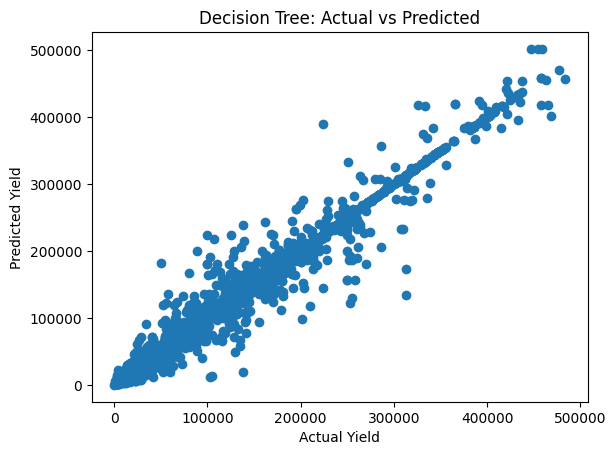

In [ ]:
plt.scatter(y_test, dt_pred)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Decision Tree: Actual vs Predicted')
plt.show()

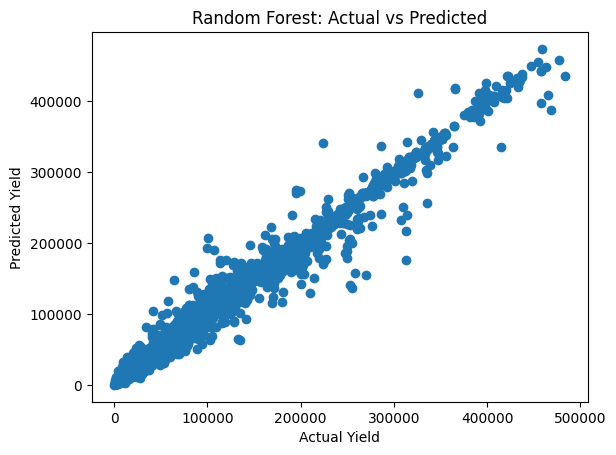

In [ ]:
plt.scatter(y_test, rf_pred)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

# LinearRegression

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)
print('Linear Regression R2 Score:', linear_r2)
print('Linear Regression MSE:', linear_mse)

Linear Regression R2 Score: 0.6584959331777018
Linear Regression MSE: 2477158477.44541


# XGBRegressor

In [ ]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
print('XGBoost R2 Score:', xgb_r2)
print('XGBoost MSE:', xgb_mse)

XGBoost R2 Score: 0.9765453338623047
XGBoost MSE: 170132592.0


## Hyperparameter Tuning for XGBoost using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# Initialize XGBRegressor
xgb_model_tuned = XGBRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model_tuned, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='r2')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best R2 score (on training data with cross-validation): {best_score}")

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best parameters: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.9}
Best R2 score (on training data with cross-validation): 0.9808534979820251


In [ ]:
# Evaluate the best model on the test set
best_xgb_model = grid_search.best_estimator_
best_xgb_pred = best_xgb_model.predict(X_test)

best_xgb_mse = mean_squared_error(y_test, best_xgb_pred)
best_xgb_r2 = r2_score(y_test, best_xgb_pred)

print(f"Best XGBoost R2 Score on Test Set: {best_xgb_r2}")
print(f"Best XGBoost MSE on Test Set: {best_xgb_mse}")

Best XGBoost R2 Score on Test Set: 0.9838482737541199
Best XGBoost MSE on Test Set: 117159176.0


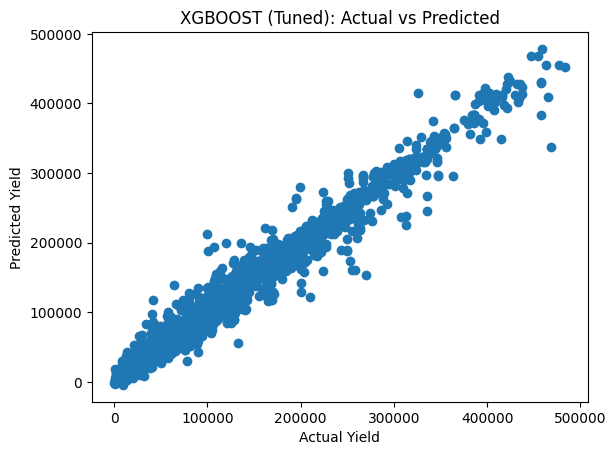

In [ ]:
plt.scatter(y_test, best_xgb_pred)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('XGBOOST (Tuned): Actual vs Predicted')
plt.show()

# Results: XGBRegressor vs LinearRegression

In [ ]:
linear_train_pred = linear_model.predict(X_train)
xgb_train_pred = xgb_model.predict(X_train)

linear_train_r2 = r2_score(y_train, linear_train_pred)
xgb_train_r2 = r2_score(y_train, xgb_train_pred)

print('Linear Regression - Train R2:', linear_train_r2)
print('Linear Regression - Test R2:', linear_r2,"\n")

print('XGboost - Train R2:', xgb_train_r2)
print('XGboost - Test R2:', xgb_r2)

Linear Regression - Train R2: 0.6520619185003138
Linear Regression - Test R2: 0.6584959331777018 

XGboost - Train R2: 0.988991916179657
XGboost - Test R2: 0.9765453338623047


In [ ]:
print('Linear Regression R2 Score:', linear_r2)
print('XGboost R2 Score:', xgb_r2)

Linear Regression R2 Score: 0.6584959331777018
XGboost R2 Score: 0.9765453338623047


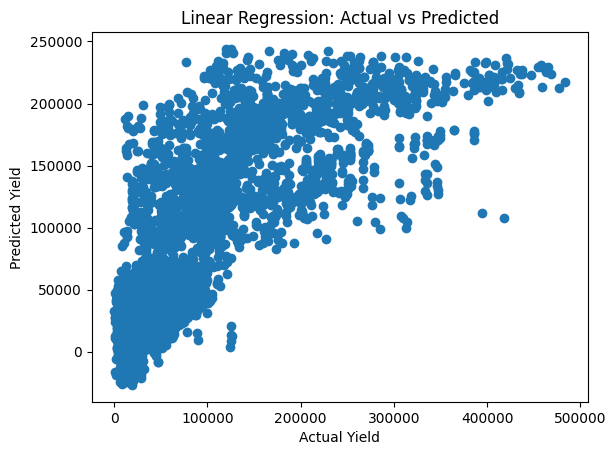

In [ ]:
plt.scatter(y_test, linear_pred)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

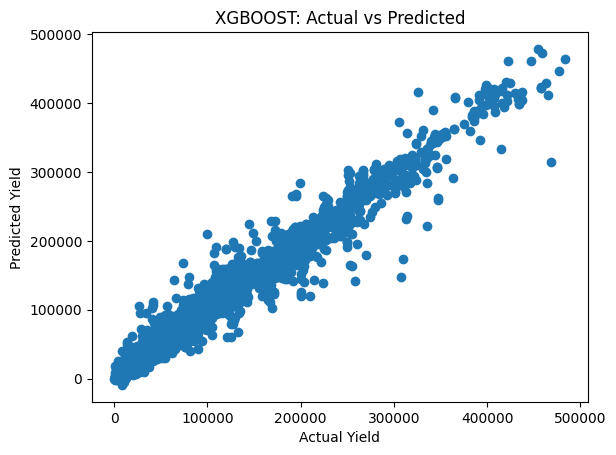

In [ ]:
plt.scatter(y_test, xgb_pred)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('XGBOOST: Actual vs Predicted')
plt.show()

# Website

In [ ]:
print(df.columns.tolist())

['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Item_Cassava', 'Item_Maize', 'Item_Plantains and others', 'Item_Potatoes', 'Item_Rice, paddy', 'Item_Sorghum', 'Item_Soybeans', 'Item_Sweet potatoes', 'Item_Wheat', 'Item_Yams', 'Area_Encoded']


In [ ]:
import joblib
from xgboost import XGBRegressor

X = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']

best_xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
best_xgb_model.fit(X, y)

joblib.dump(best_xgb_model, 'yield_model.pkl')
print("Model saved successfully with all 15 features!")

Model saved successfully with all 15 features!
